# Lab 6: Data Visualization and Interpretation using Plotly

## Imports

In [1]:
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

## Load dataset

In [2]:
data = px.data.gapminder()
data

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


## Tasks:

### 1. Scatter Plot with Slider (Animation)
    1. Plot GDP per capita (gdpPercap) vs life expectancy (lifeExp) for all countries.
    2. Use population (pop) to size the points.
    3. Color points by continent.
    4. Add a slider to move through different years.
    5. Title: "GDP vs Life Expectancy Over Time".
    6. Label the x-axis as "GDP per Capita (USD)" and the y-axis as "Life Expectancy (Years)".
    7. Ensure hover tooltips display country names.

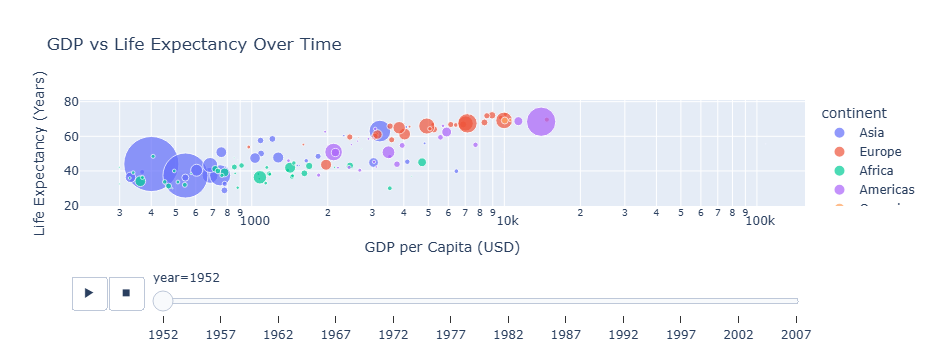

In [3]:
fig = px.scatter(
    data,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    animation_frame="year",
    hover_name="country",
    size_max=60,
    log_x=True, 
    title="GDP vs Life Expectancy Over Time",
    labels={
        "gdpPercap": "GDP per Capita (USD)",
        "lifeExp": "Life Expectancy (Years)"
    }
)

fig.show()

### 2. Line Plot with Dropdown Selector
    1. Plot life expectancy (lifeExp) versus year (year) for multiple countries (India, China, USA, Brazil).
    2. Add a dropdown menu allowing selection of a country whose line is visible.
    3. Use distinct line colors for each country.
    4. Title: "Life Expectancy Comparison by Country".
    5. Label the x-axis as "Year" and the y-axis as "Life Expectancy (Years)".
    6. Place the legend at the bottom of the plot.

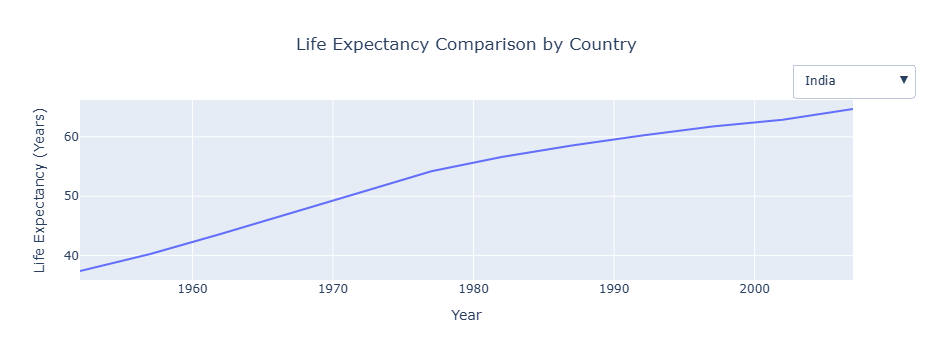

In [4]:
countries = ["India", "China", "United States", "Brazil"]

filtered = data[data["country"].isin(countries)]

fig = go.Figure()

for country in countries:
    country_data = filtered[filtered["country"] == country]
    
    fig.add_trace(
        go.Scatter(
            x=country_data["year"],
            y=country_data["lifeExp"],
            mode="lines",
            name=country,
            visible=True if country == "India" else False
        )
    )

buttons = []

for i, country in enumerate(countries):
    visibility = [False] * len(countries)
    visibility[i] = True

    buttons.append(
        dict(
            label=country,
            method="update",
            args=[{"visible": visibility}]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1, xanchor="center",
            y=1.2, yanchor="top"
        )
    ],
    title=dict(
        text="Life Expectancy Comparison by Country",
        x=0.5
    ),
    xaxis_title="Year",
    yaxis_title="Life Expectancy (Years)",
    legend=dict(orientation="h", y=-0.2)
)

fig.show()

### 3. Bar Plot with Buttons (Switch Between Variables)

1. Plot population (pop) by continent for 2007.
2. Add buttons to toggle between population and GDP per capita (gdpPercap).
3. Use grouped bars for clarity.
4. Title: "Continent Comparison (2007)".
5. Label the x-axis as "Continent" and the y-axis as "Value".
6. Display the legend at the top-right corner.

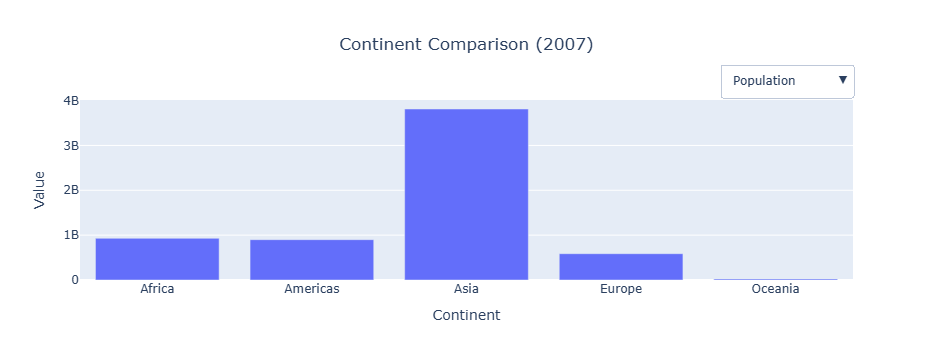

In [5]:
data_2007 = data[data["year"] == 2007]
data_grouped = data_2007.groupby("continent", as_index=False).agg({"pop": "sum", "gdpPercap": "mean"})

fig = go.Figure()
fig.add_bar(x=data_grouped["continent"], y=data_grouped["pop"], name="Population")

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label="Population",
                    method="update",
                    args=[{"y": [data_grouped["pop"]],
                           "name": "Population"}]
                ),
                dict(
                    label="GDP per Capita",
                    method="update",
                    args=[{"y": [data_grouped["gdpPercap"]],
                           "name": "GDP per Capita"}]
                )
            ],
            direction="down",
            x=1, xanchor="right",
            y=1.2, yanchor="top"
        )
    ]
)

fig.update_layout(
    title=dict(
        text="Continent Comparison (2007)",
        x=0.5
    ),
    xaxis_title="Continent",
    yaxis_title="Value",
    barmode="group",
    legend=dict(
        orientation="h",
        x=1,
        xanchor="right",
        y=1.02,
        yanchor="bottom"
    )
)

fig.show()

### 4. Map with Projection Selector

1. Plot life expectancy (lifeExp) by country on a world map for 2007.
2. Use population (pop) to size the markers.
3. Add hover tooltips to show country names.
4. Add buttons to switch between map projections (Natural Earth, Mercator, Orthographic).
5. Title: "World Map of Life Expectancy (2007)".

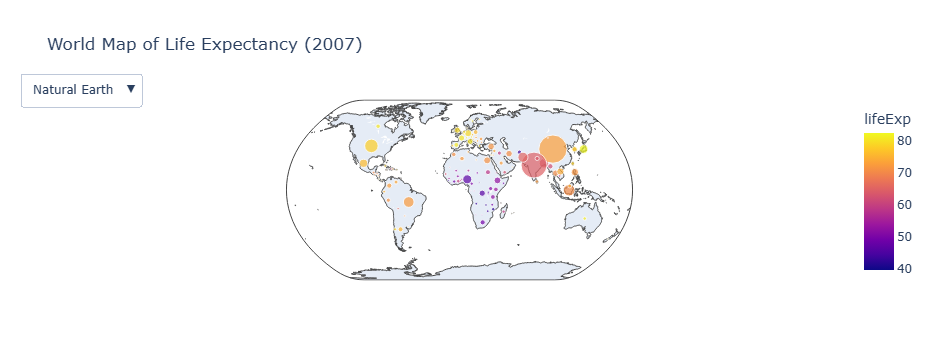

In [6]:
data_2007 = data[data["year"] == 2007]

fig = px.scatter_geo(
    data_2007,
    locations="iso_alpha",
    size="pop",
    color="lifeExp",
    hover_name="country",
    projection="natural earth",
    title="World Map of Life Expectancy (2007)"
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label="Natural Earth",
                    method="relayout",
                    args=[{"geo.projection.type": "natural earth"}]
                ),
                dict(
                    label="Mercator",
                    method="relayout",
                    args=[{"geo.projection.type": "mercator"}]
                ),
                dict(
                    label="Orthographic",
                    method="relayout",
                    args=[{"geo.projection.type": "orthographic"}]
                )
            ],
            direction="down",
            x=0, xanchor="center",
            y=1.15, yanchor="top"
        )
    ]
)

fig.show()

### 5. Animated Scatter Plot with Play/Pause Controls
    1. Plot GDP per capita (gdpPercap) vs life expectancy (lifeExp) across all years.
    2. Use population (pop) to size the points.
    3. Color points by continent.
    4. Add play/pause controls to animate the visualization automatically across years.
    5. Title: "Global Development Trends (1952–2007)".
    6. Label the x-axis as "GDP per Capita (USD)" and the y-axis as "Life Expectancy (Years)".
    7. Ensure hover tooltips display country names.

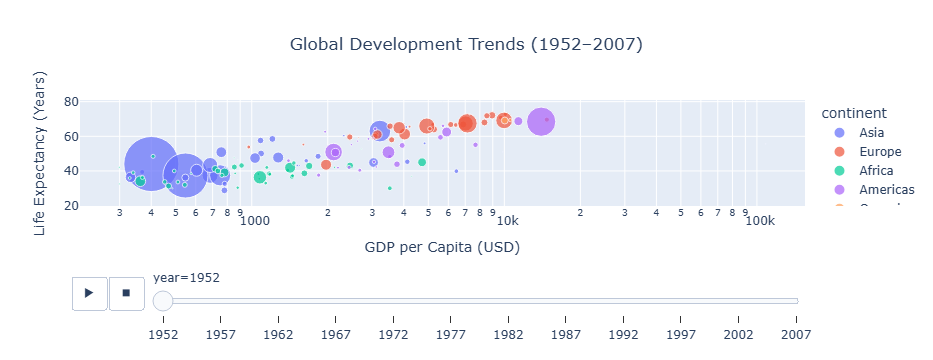

In [7]:
fig = px.scatter(
    data,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    animation_frame="year",
    animation_group="country",
    size_max=60,
    log_x=True,
    title="Global Development Trends (1952–2007)",
    labels={
        "gdpPercap": "GDP per Capita (USD)",
        "lifeExp": "Life Expectancy (Years)"
    }
)

fig.update_layout(title_x=0.5)

fig.show()

### 6. 3D Scatter Plot
    1. Plot GDP per capita (gdpPercap), life expectancy (lifeExp), and population (pop) in 2007.
    2. Use continent for color coding.
    3. Size points by population.
    4. Title: "3D Scatter: GDP, Life Expectancy, Population (2007)".
    5. Label axes appropriately.

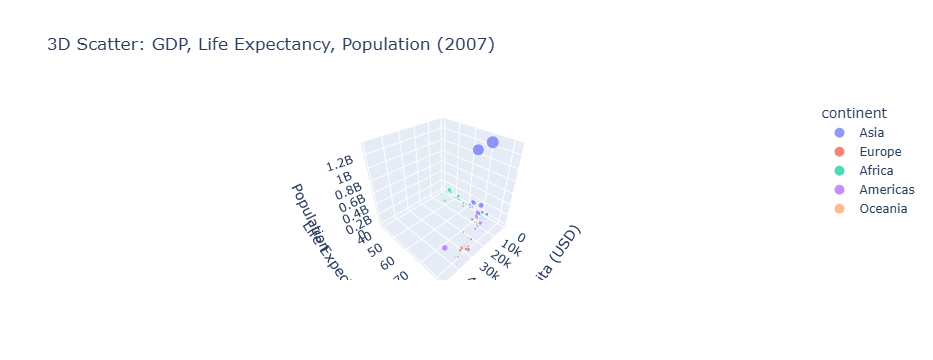

In [8]:
data_2007_3d = data[data['year'] == 2007]

fig = px.scatter_3d(
    data_2007_3d,
    x='gdpPercap',
    y='lifeExp',
    z='pop',
    color='continent',
    size='pop',
    hover_name='country',
    title='3D Scatter: GDP, Life Expectancy, Population (2007)',
    labels={
        'gdpPercap': 'GDP per Capita (USD)',
        'lifeExp': 'Life Expectancy (Years)',
        'pop': 'Population'
    })
fig.show()

### 7. Heatmap
    1. Compute the correlation matrix for life expectancy (lifeExp), GDP per capita (gdpPercap), and population (pop).
    2. Plot the correlation matrix as a heatmap.
    3. Display numeric correlation values inside each heatmap cell.
    4. Title: "Correlation Heatmap of Development Indicators".
    5. Use a diverging color scale for better contrast between positive and negative correlations.

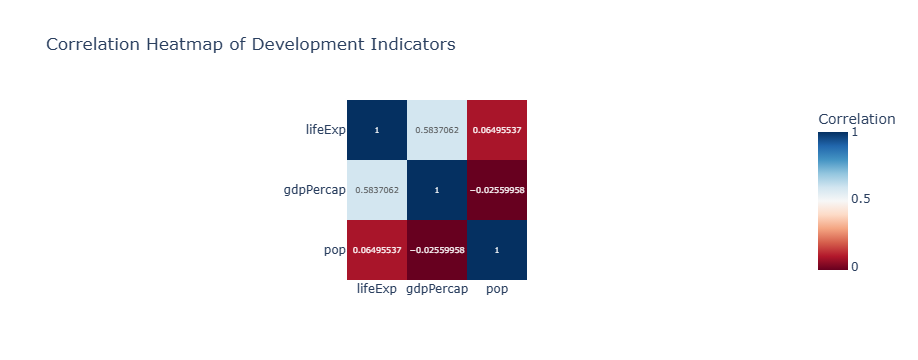

In [9]:
corr_data = data[["lifeExp", "gdpPercap", "pop"]]

corr_matrix = corr_data.corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="RdBu", 
    title="Correlation Heatmap of Development Indicators",
    labels=dict(color="Correlation"),
)

fig.show()

### 8. Pie Chart
    1. Create a pie chart showing population share (pop) by continent in the year 2007.
    2. Aggregate total population for each continent.
    3. Display percentage labels on each slice.
    4. Title: "Population Share by Continent (2007)".
    5. Use contrasting colors for clear distinction between slices.

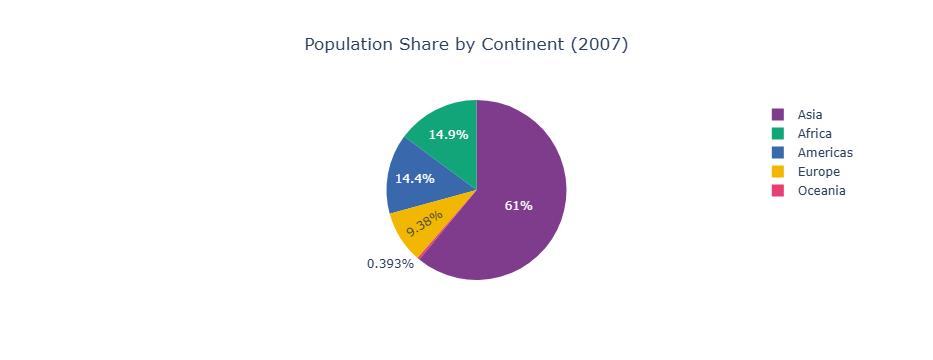

In [10]:
data_2007 = data[data["year"] == 2007]

pop_continent = data_2007.groupby("continent", as_index=False)["pop"].sum()

fig = px.pie(
    pop_continent,
    values="pop",
    names="continent",
    title="Population Share by Continent (2007)",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(title_x=0.5)

fig.show()

### 9. Treemap of Population
    1. Create a treemap visualization for the year 2007.
    2. Size blocks according to population (pop).
    3. Color blocks by continent.
    4. Ensure hover tooltips display country names.
    5. Title: "Population Treemap (2007)".

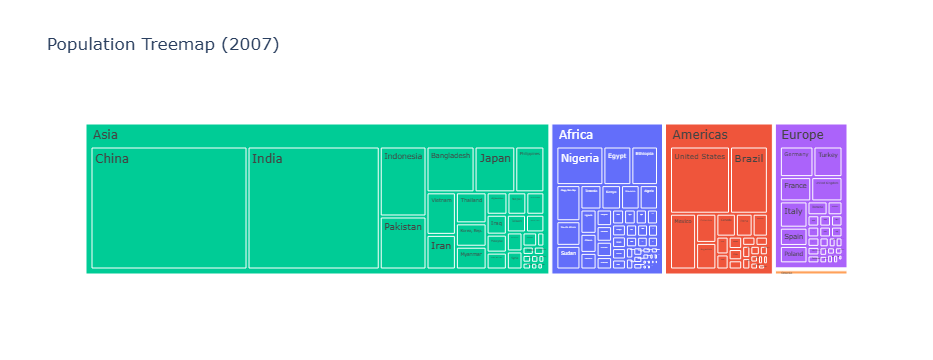

In [11]:
data_2007 = data[data["year"] == 2007]

fig = px.treemap(
    data_2007,
    path=["continent", "country"],
    values="pop",
    color="continent",
    hover_name="country",
    title="Population Treemap (2007)"
)

fig.show()

### 10. Sunburst Chart
    1. Title: "Sunburst of Population (2007)".
    2. Inner ring = continent, outer ring = country.

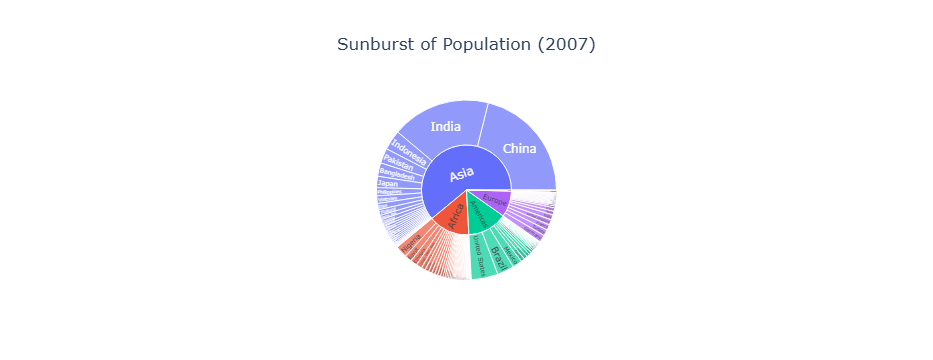

In [12]:
data_2007 = data[data["year"] == 2007]

fig = px.sunburst(
    data_2007,
    path=["continent", "country"],
    values="pop",
    title="Sunburst of Population (2007)"
)
fig.update_layout(title_x=0.5)
fig.show()